In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [45]:
artist_exposures = pd.read_csv("experiments/babyLFM5k/results/artist_exposures.csv")

In [47]:
countries_exposures = artist_exposures.iloc[:, [1] + list(range(3, artist_exposures.shape[1]))].groupby("country").sum()

In [48]:
english_countries = countries_exposures.index.isin(["AU","CA","UK","US"])

In [49]:
# Load catalog representation
tracks_catalog = pd.read_csv("experiments/babyLFM5k/input/tracks.tsv", sep="\t", header=None, names=["track_id","artist","title","country","gender"])
catalog_countries_representation = tracks_catalog.groupby("country").size() / len(tracks_catalog)

# Calculate catalog proportions for each region
english_countries_list = ["AU","CA","UK","US"]
spanish_countries_list = ["ES","MX","AR","CO","CL","PE","VE","EC","BO","PY","UY"]
german_countries_list = ["DE","AT","CH","LI"]

english_catalog_prop = catalog_countries_representation[catalog_countries_representation.index.isin(english_countries_list)].sum()
spanish_catalog_prop = catalog_countries_representation[catalog_countries_representation.index.isin(spanish_countries_list)].sum()
german_catalog_prop = catalog_countries_representation[catalog_countries_representation.index.isin(german_countries_list)].sum()

print(f"English-speaking countries catalog representation: {english_catalog_prop:.3f}")
print(f"Spanish-speaking countries catalog representation: {spanish_catalog_prop:.3f}")
print(f"German-speaking countries catalog representation: {german_catalog_prop:.3f}")

English-speaking countries catalog representation: 0.741
Spanish-speaking countries catalog representation: 0.026
German-speaking countries catalog representation: 0.018


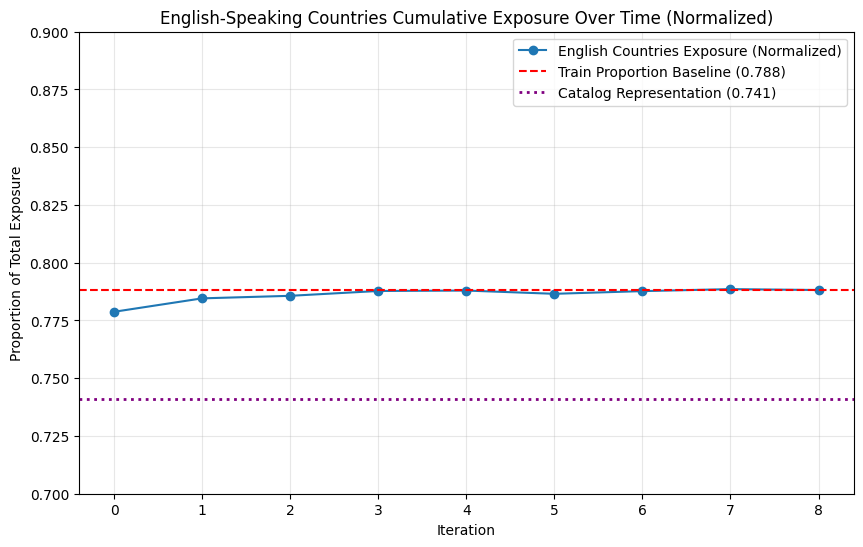

In [50]:
# Plot normalized cumulative exposure of English countries over time
exposure_over_time = countries_exposures[english_countries].sum(axis=0)
cumulative_exposure = exposure_over_time.cumsum()
total_cumulative = countries_exposures.sum(axis=0).cumsum()
normalized_cumulative = cumulative_exposure / total_cumulative

# Calculate train proportion baseline
total_per_iteration = countries_exposures.sum(axis=0)
train_proportion = exposure_over_time.mean() / total_per_iteration.mean()

plt.figure(figsize=(10, 6))
plt.plot(range(len(normalized_cumulative)), normalized_cumulative.values, marker='o', label='English Countries Exposure (Normalized)')
plt.axhline(y=train_proportion, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion:.3f})')
plt.axhline(y=english_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({english_catalog_prop:.3f})')
plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('English-Speaking Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(normalized_cumulative)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 0.9)
plt.show()

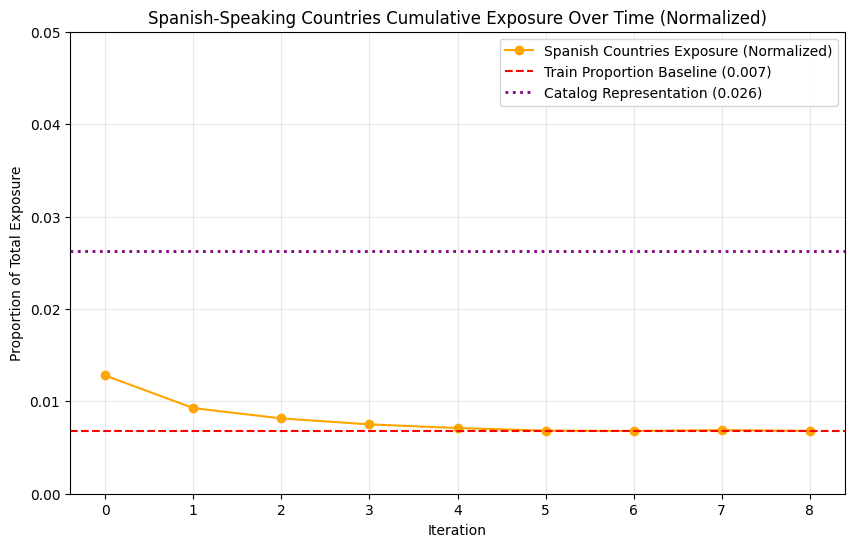

In [51]:
# Plot normalized cumulative exposure of Spanish countries over time
spanish_countries = countries_exposures.index.isin(["ES","MX","AR","CO","CL","PE","VE","EC","BO","PY","UY"])
exposure_over_time_spanish = countries_exposures[spanish_countries].sum(axis=0)
cumulative_exposure_spanish = exposure_over_time_spanish.cumsum()
total_cumulative = countries_exposures.sum(axis=0).cumsum()
normalized_cumulative_spanish = cumulative_exposure_spanish / total_cumulative

# Calculate train proportion baseline
total_per_iteration = countries_exposures.sum(axis=0)
train_proportion_spanish = exposure_over_time_spanish.mean() / total_per_iteration.mean()

plt.figure(figsize=(10, 6))
plt.plot(range(len(normalized_cumulative_spanish)), normalized_cumulative_spanish.values, marker='o', label='Spanish Countries Exposure (Normalized)', color='orange')
plt.axhline(y=train_proportion_spanish, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_spanish:.3f})')
plt.axhline(y=spanish_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({spanish_catalog_prop:.3f})')
plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('Spanish-Speaking Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(normalized_cumulative_spanish)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.05)
plt.show()

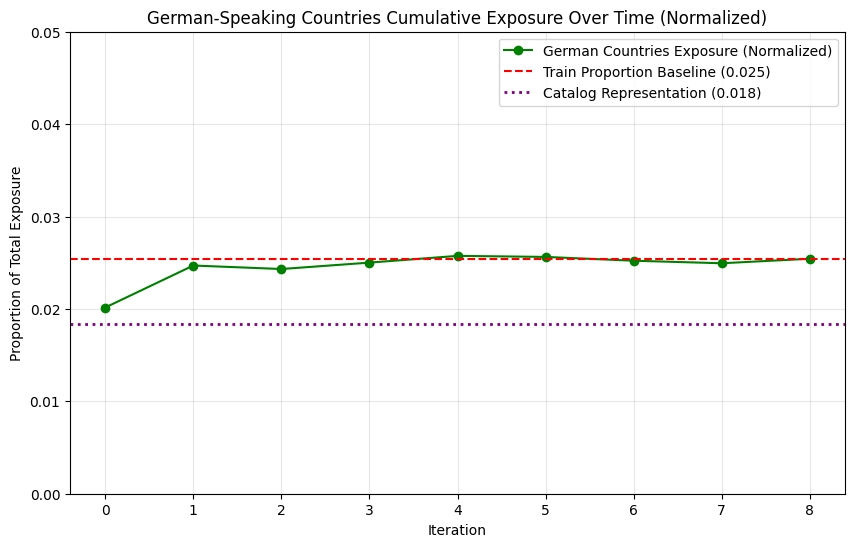

In [52]:
# Plot normalized cumulative exposure of German countries over time
german_countries = countries_exposures.index.isin(["DE","AT","CH","LI"])
exposure_over_time_german = countries_exposures[german_countries].sum(axis=0)
cumulative_exposure_german = exposure_over_time_german.cumsum()
total_cumulative = countries_exposures.sum(axis=0).cumsum()
normalized_cumulative_german = cumulative_exposure_german / total_cumulative

# Calculate train proportion baseline
total_per_iteration = countries_exposures.sum(axis=0)
train_proportion_german = exposure_over_time_german.mean() / total_per_iteration.mean()

plt.figure(figsize=(10, 6))
plt.plot(range(len(normalized_cumulative_german)), normalized_cumulative_german.values, marker='o', label='German Countries Exposure (Normalized)', color='green')
plt.axhline(y=train_proportion_german, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_german:.3f})')
plt.axhline(y=german_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({german_catalog_prop:.3f})')
plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('German-Speaking Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(normalized_cumulative_german)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.05)
plt.show()

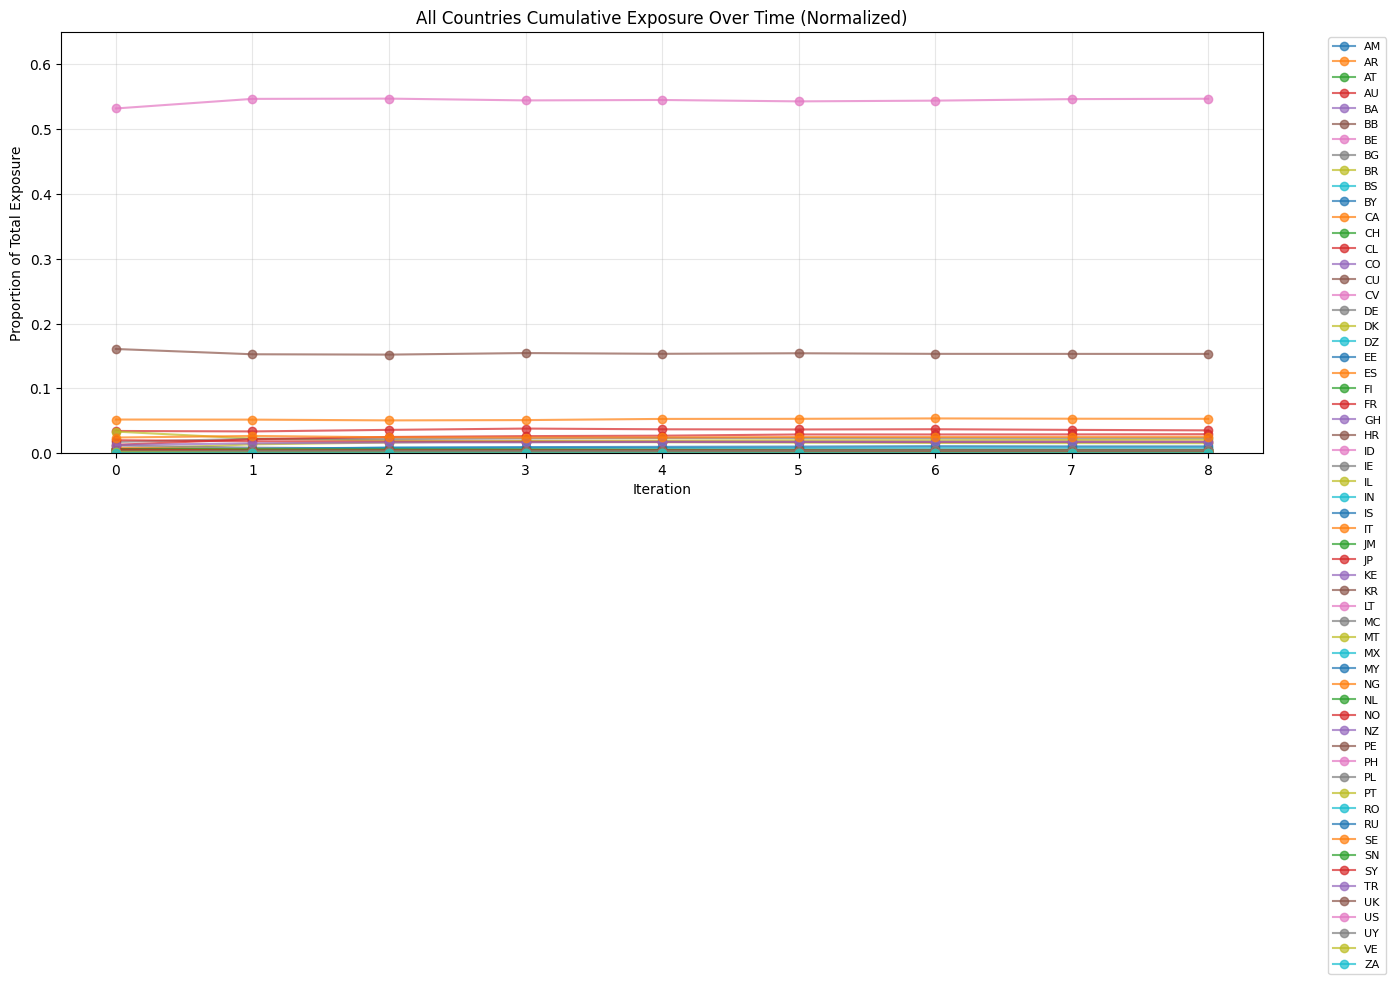

In [53]:
# Plot normalized cumulative exposure of all countries over time
plt.figure(figsize=(14, 8))

total_cumulative = countries_exposures.sum(axis=0).cumsum()

for country in countries_exposures.index:
    cumulative = countries_exposures.loc[country].cumsum()
    normalized = cumulative / total_cumulative
    plt.plot(range(len(normalized)), normalized.values, marker='o', label=country, alpha=0.7)

plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('All Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(countries_exposures.columns)))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.65)
plt.tight_layout()
plt.show()